<h2>Formating of DB-Data<h2>

In [1]:
from hilfsfunktionen.formating import get_unchanged_table, get_formated_table, get_table_with_keys, create_n_sentences
df_collection = {}
df_collection["unchanged_table"] = get_unchanged_table()
df_collection["formated_table"] = get_formated_table()
df_collection["formated_table_with_keys"] = get_table_with_keys(df_collection["formated_table"])
df_collection["n_sentences"] = {}
for n in [1, 5, 20, 50, 100]:
    df_collection["n_sentences"][f"{n}"] = create_n_sentences(df_collection["formated_table_with_keys"], n)

    

<h2>Model Creation<h2>

In [2]:
from hilfsfunktionen.model_training import (
    ModelConfig, 
    ModelTrainer, 
    ModelRepository, 
    ExperimentRunner
)
from pathlib import Path
seeds = [1, 42]
models = {}  

for seed in seeds:
    base_config = ModelConfig(
        vector_size = 50,      # Dimension der Wortvektoren; guter Kompromiss zwischen Ausdrucksstärke und Rechenaufwand
        window = 4,             # Kleines Kontextfenster; betont lokale, eher syntaktische Beziehungen
        epochs = 30,            # Viele Trainingsdurchläufe; bessere Anpassung, aber erhöhtes Overfitting-Risiko
        min_count = 1,          # Alle Wörter werden berücksichtigt; seltene Wörter sind jedoch oft verrauscht
        negative = 5,           # Anzahl negativer Beispiele; Standardwert mit gutem Qualitäts-/Zeit-Verhältnis
        sample = 1e-3,             # Subsampling häufiger Wörter; verbessert Semantik, kann bei kleinen Korpora schaden
        hs = 0,                 # Hierarchical Softmax deaktiviert; Training erfolgt ausschließlich via Negative Sampling
        alpha = 0.025,          # Start-Lernrate; stabiler Trainingsbeginn, bei vielen Epochen kritisch
        seed = seed,               # Faester Zufallsstart; sorgt für Reproduzierbarkeit   
    )
    
    GRID = {
        "vector_size": [50, 100, 150, 200, 300],
        "window": [2, 4, 6, 10, 15, 20],
        "sg": [0, 1],
        "epochs": [30],
        "negative": [5],
        "sample": [1e-3],
        "hs": [0],
        "alpha": [0.025],
        "seed": [seed]
    }
    
    trainer = ModelTrainer()
    repository = ModelRepository(base_dir=Path.cwd())
    runner = ExperimentRunner(trainer, repository, base_config)
    
    
    models[seed]  = runner.run_grid_search(
        sentences=df_collection["n_sentences"]["20"],
        param_grid=GRID,
        #n_sentences_tokenized=df_collection["n_sentences"],
        num_sentences=10000, # Begrenzung der Trainingssätze; beschleunigt Training, limitiert Informationsgehalt
        verbose=True
    )

Started Model-Creation with: CBOW, vs=50, win=2, ep=30
Modell geladen: /workspace/models/CBOW_vs_50_win_2_ep_30_nsent_10000_sentlen_340_mc_1_neg_5_sample_0.001_hs_0_alpha_0.025_seed_1.model
Loaded model.
Started Model-Creation with: SGNS, vs=50, win=2, ep=30
Modell geladen: /workspace/models/SGNS_vs_50_win_2_ep_30_nsent_10000_sentlen_340_mc_1_neg_5_sample_0.001_hs_0_alpha_0.025_seed_1.model
Loaded model.
Started Model-Creation with: CBOW, vs=50, win=4, ep=30
Modell geladen: /workspace/models/CBOW_vs_50_win_4_ep_30_nsent_10000_sentlen_340_mc_1_neg_5_sample_0.001_hs_0_alpha_0.025_seed_1.model
Loaded model.
Started Model-Creation with: SGNS, vs=50, win=4, ep=30
Modell geladen: /workspace/models/SGNS_vs_50_win_4_ep_30_nsent_10000_sentlen_340_mc_1_neg_5_sample_0.001_hs_0_alpha_0.025_seed_1.model
Loaded model.
Started Model-Creation with: CBOW, vs=50, win=6, ep=30
Modell geladen: /workspace/models/CBOW_vs_50_win_6_ep_30_nsent_10000_sentlen_340_mc_1_neg_5_sample_0.001_hs_0_alpha_0.025_seed_1.

<h2>Durchschnittliche Satzvektoren berechnen<h2>

In [3]:
from hilfsfunktionen.sentence_vectors import create_average_sentence_vectors

average_sentence_vectors = {} 
for seed in seeds:
    average_sentence_vectors[seed] = []
    for model in models[seed]:
        average_sentence_vectors[seed].append([create_average_sentence_vectors(model, df_collection["formated_table_with_keys"], base_dir = Path.cwd(), verbose=False),model[1]])
    print("Finished for Seed: ", seed)

Finished for Seed:  1
Finished for Seed:  42


<h2>Vektoren-Test Textbasiert<h2>

In [4]:
from hilfsfunktionen.collect_test_data import get_all_grid_results
    
test_results = get_all_grid_results(average_sentence_vectors, models, df_collection["formated_table_with_keys"] , verbose=False)

Tests abgeschlossen. 60 Modelle getestet.


In [14]:
import pandas as pd
rows = []
print(test_results)
for r in test_results:
    p = r["params"]
    rows.append({
        "vector_size": p["Vector Size"],
        "window": p["Window"],
        "algorithm": p["Algorithmus"],
        "ssmq": r["ssmq"],
        "nd": r["nd_norm"],
        "rs": r["rs_mean"],
        "fc": r["fc"]
    })

df = pd.DataFrame(rows)
df.head

[{'params': {'Vector Size': 50, 'Window': 2, 'Algorithmus': 'CBOW', 'Kleinste Worthäufigkeit': 1, 'Workers': 4, 'Epochs': 30, 'Satzanzahl': 10000, 'Satzlänge': 340, 'Negative Sampling': 5, 'Sample': 0.001, 'Hierarchical Softmax': 0, 'Alpha': 0.025}, 'nd': np.float64(0.9516800663469832), 'rs_mean': np.float64(0.5640769754839493), 'rs_5': 0.5847619047619047, 'rs_10': 0.563978798978799, 'rs_20': 0.5434902227111444, 'fc': 0.5880660340585255, 'kvc': {'model_score': np.float64(0.04730671153595442), 'avg_proximity_score': np.float64(0.2836363636363637), 'avg_weighted_proximity_score': np.float64(0.04730671153595442), 'total_found_values': 156, 'total_possible_values': 550, 'overall_recall': 0.28363636363636363, 'keys_evaluated': 50, 'topn': 20, 'filter_keys': True, 'max_fetch': 10000, 'interpretation': 'Ungenügend - Keys kodieren ihre Zeilenwerte kaum'}, 'used_sentence_vectors': {'model_info': {'Vector Size': 50, 'Window': 2, 'Algorithmus': 'CBOW', 'Kleinste Worthäufigkeit': 1, 'Workers': 4, 

<bound method NDFrame.head of     vector_size  window algorithm      ssmq        nd        rs        fc
0            50       2      CBOW  0.685156  0.951680  0.564077  0.588066
1            50       2      SGNS  0.561803  0.311527  0.667553  0.672842
2            50       4      CBOW  0.631189  1.000000  0.456450  0.514821
3            50       4      SGNS  0.545776  0.269487  0.679833  0.625065
4            50       6      CBOW  0.528984  0.803797  0.387317  0.470933
5            50       6      SGNS  0.503318  0.272032  0.607178  0.590595
6            50      10      CBOW  0.427854  0.738197  0.195329  0.543651
7            50      10      SGNS  0.471058  0.160788  0.619767  0.564689
8            50      15      CBOW  0.541640  0.981722  0.292366  0.504704
9            50      15      SGNS  0.441809  0.091116  0.618037  0.527277
10           50      20      CBOW  0.577313  0.886537  0.390104  0.581501
11           50      20      SGNS  0.407167  0.061791  0.569758  0.518754
12      

<h2>Visualisierung<h2>

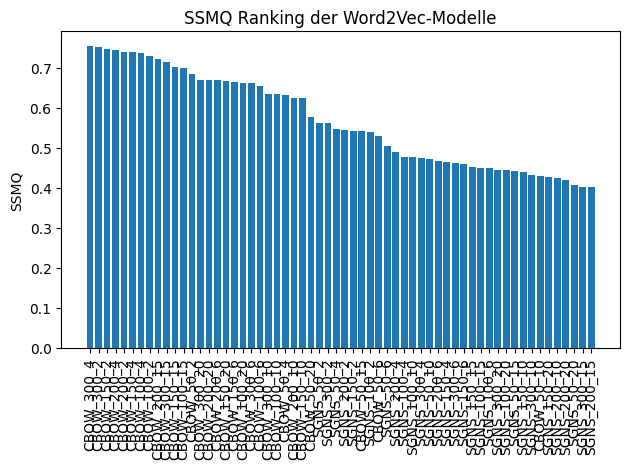

In [15]:
import matplotlib.pyplot as plt

df_sorted = df.sort_values("ssmq", ascending=False).reset_index(drop=True)

plt.figure()
plt.bar(
    range(len(df_sorted)),
    df_sorted["ssmq"]
)
plt.xticks(
    range(len(df_sorted)),
    df_sorted["algorithm"] + "_" +
    df_sorted["vector_size"].astype(str) + "_" +
    df_sorted["window"].astype(str),
    rotation=90
)
plt.ylabel("SSMQ")
plt.title("SSMQ Ranking der Word2Vec-Modelle")
plt.tight_layout()
plt.show()

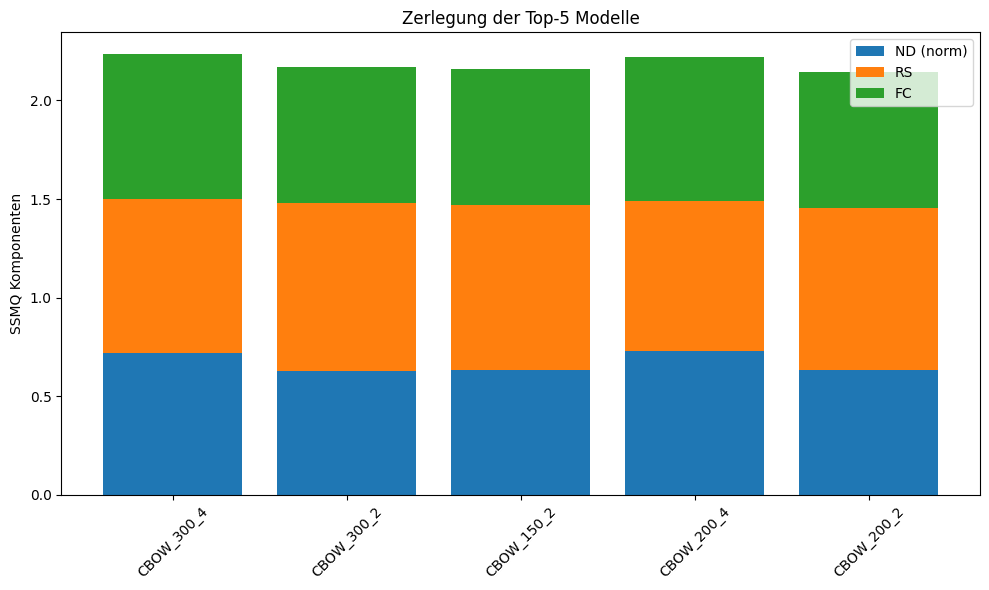

/tmp/ipykernel_1205/1925570175.py:87: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



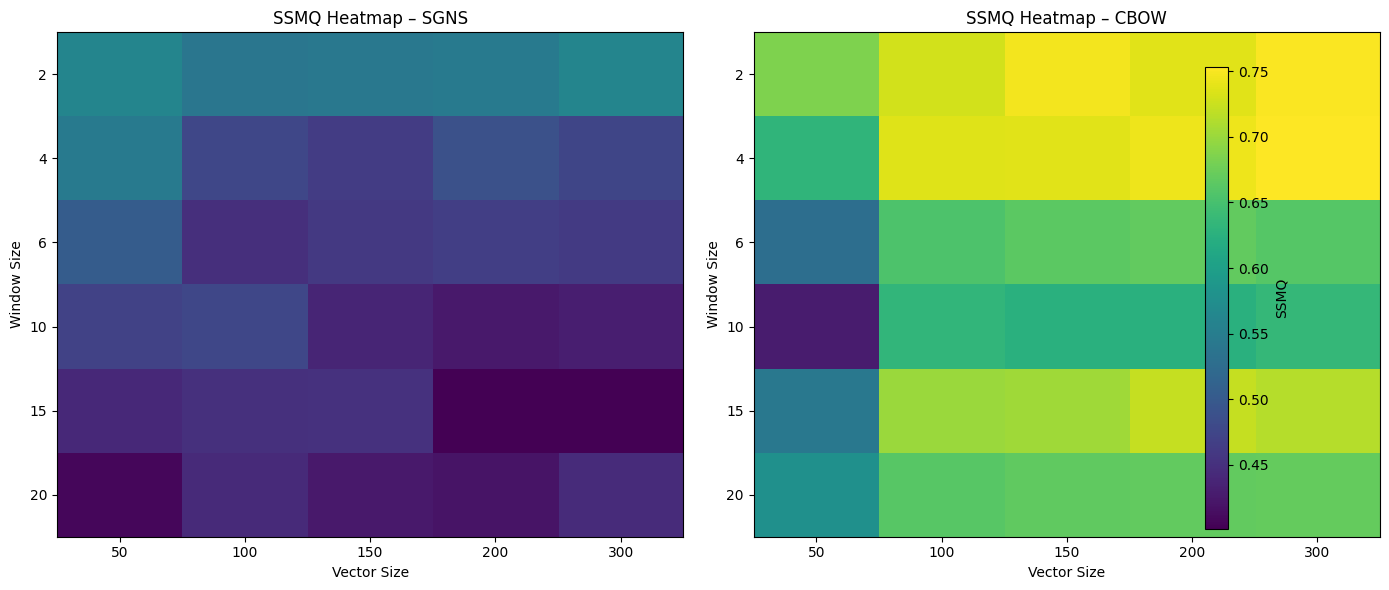

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# Bar-Chart (bleibt unverändert)
top5 = df_sorted.head(5)

plt.figure(figsize=(10, 6))
plt.bar(range(5), top5["nd"], label="ND (norm)")
plt.bar(range(5), top5["rs"], bottom=top5["nd"], label="RS")
plt.bar(
    range(5),
    top5["fc"],
    bottom=top5["nd"] + top5["rs"],
    label="FC"
)

plt.xticks(
    range(5),
    top5["algorithm"] + "_" +
    top5["vector_size"].astype(str) + "_" +
    top5["window"].astype(str),
    rotation=45
)
plt.ylabel("SSMQ Komponenten")
plt.title("Zerlegung der Top-5 Modelle")
plt.legend()
plt.tight_layout()
plt.show()

# Heatmaps nebeneinander mit gemeinsamer Skala
# Zuerst die Daten vorbereiten
sgns = df[df["algorithm"] == "SGNS"]
cbow = df[df["algorithm"] == "CBOW"]

heatmap_sgns = sgns.pivot(
    index="window",
    columns="vector_size",
    values="ssmq"
)

heatmap_cbow = cbow.pivot(
    index="window",
    columns="vector_size",
    values="ssmq"
)

# Gemeinsame Werteskala bestimmen
all_ssmq_values = np.concatenate([
    heatmap_sgns.values.flatten(),
    heatmap_cbow.values.flatten()
])

# Entferne NaN-Werte
all_ssmq_values = all_ssmq_values[~np.isnan(all_ssmq_values)]

# Bestimme absolut besten und schlechtesten Wert
vmin = all_ssmq_values.min()
vmax = all_ssmq_values.max()

# Erstelle Subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# SGNS Heatmap
im1 = axes[0].imshow(heatmap_sgns.values, vmin=vmin, vmax=vmax, aspect='auto')
axes[0].set_xticks(range(len(heatmap_sgns.columns)))
axes[0].set_xticklabels(heatmap_sgns.columns)
axes[0].set_yticks(range(len(heatmap_sgns.index)))
axes[0].set_yticklabels(heatmap_sgns.index)
axes[0].set_xlabel("Vector Size")
axes[0].set_ylabel("Window Size")
axes[0].set_title("SSMQ Heatmap – SGNS")

# CBOW Heatmap
im2 = axes[1].imshow(heatmap_cbow.values, vmin=vmin, vmax=vmax, aspect='auto')
axes[1].set_xticks(range(len(heatmap_cbow.columns)))
axes[1].set_xticklabels(heatmap_cbow.columns)
axes[1].set_yticks(range(len(heatmap_cbow.index)))
axes[1].set_yticklabels(heatmap_cbow.index)
axes[1].set_xlabel("Vector Size")
axes[1].set_ylabel("Window Size")
axes[1].set_title("SSMQ Heatmap – CBOW")

# Gemeinsame Colorbar
cbar = fig.colorbar(im2, ax=axes, orientation='vertical', fraction=0.046, pad=0.04)
cbar.set_label("SSMQ")

plt.tight_layout()
plt.show()

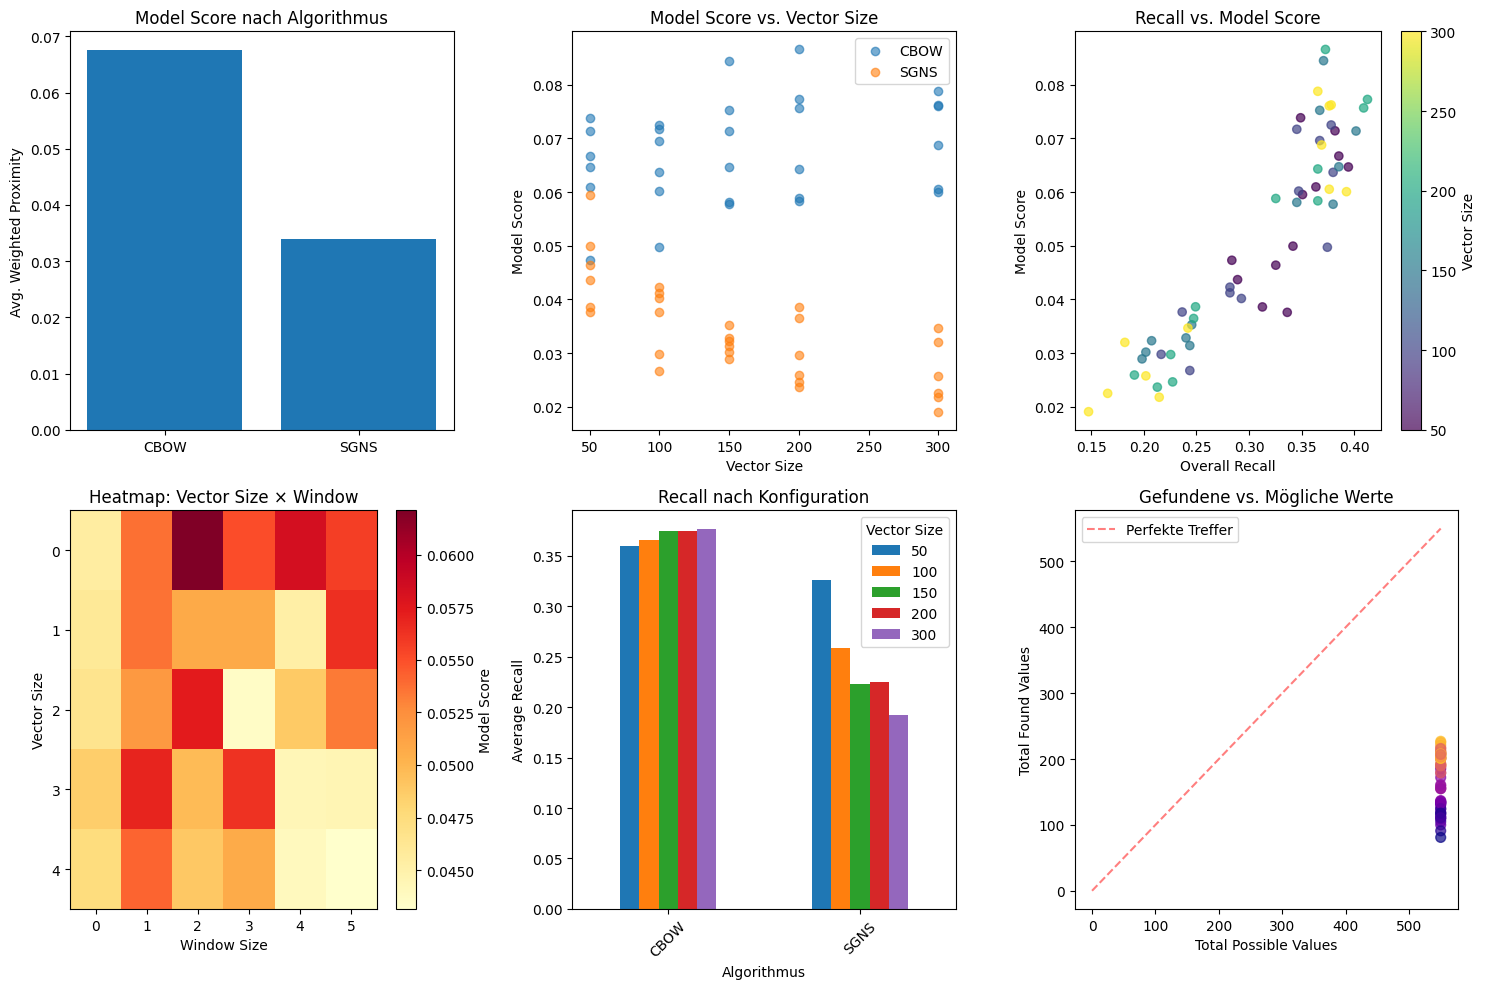

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib import cm

# Daten vorbereiten
def prepare_kvc_data(test_results):
    kvc_data = []
    for result in test_results:
        params = result['params']
        kvc = result['kvc']
        kvc_data.append({**params, **kvc})
    return pd.DataFrame(kvc_data)

df = prepare_kvc_data(test_results)

# 1. Hauptvisualisierung: Model Score vs. Parameter
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Model Score nach Algorithmus
algorithm_scores = df.groupby('Algorithmus')['model_score'].mean()
axes[0,0].bar(algorithm_scores.index, algorithm_scores.values)
axes[0,0].set_title('Model Score nach Algorithmus')
axes[0,0].set_ylabel('Avg. Weighted Proximity')

# Model Score vs. Vector Size (farbig nach Algorithmus)
for algo in df['Algorithmus'].unique():
    subset = df[df['Algorithmus'] == algo]
    axes[0,1].scatter(subset['Vector Size'], subset['model_score'], 
                     label=algo, alpha=0.6)
axes[0,1].set_title('Model Score vs. Vector Size')
axes[0,1].set_xlabel('Vector Size')
axes[0,1].set_ylabel('Model Score')
axes[0,1].legend()

# Recall vs. Model Score
scatter = axes[0,2].scatter(df['overall_recall'], df['model_score'],
                           c=df['Vector Size'], cmap='viridis', alpha=0.7)
axes[0,2].set_title('Recall vs. Model Score')
axes[0,2].set_xlabel('Overall Recall')
axes[0,2].set_ylabel('Model Score')
plt.colorbar(scatter, ax=axes[0,2], label='Vector Size')

# Heatmap: Vector Size × Window Size
pivot = df.pivot_table(values='model_score', 
                       index='Vector Size', 
                       columns='Window',
                       aggfunc='mean')
im = axes[1,0].imshow(pivot.values, cmap='YlOrRd', aspect='auto')
axes[1,0].set_title('Heatmap: Vector Size × Window')
axes[1,0].set_xlabel('Window Size')
axes[1,0].set_ylabel('Vector Size')
plt.colorbar(im, ax=axes[1,0], label='Model Score')

# Erfolgsquote (Recall) nach Konfiguration
recall_by_config = df.groupby(['Algorithmus', 'Vector Size'])['overall_recall'].mean().unstack()
recall_by_config.plot(kind='bar', ax=axes[1,1])
axes[1,1].set_title('Recall nach Konfiguration')
axes[1,1].set_xlabel('Algorithmus')
axes[1,1].set_ylabel('Average Recall')
axes[1,1].tick_params(axis='x', rotation=45)

# Gefundene vs. Mögliche Werte
axes[1,2].scatter(df['total_possible_values'], df['total_found_values'],
                 c=df['model_score'], cmap='plasma', alpha=0.7, s=50)
axes[1,2].plot([0, df['total_possible_values'].max()], 
              [0, df['total_possible_values'].max()], 
              'r--', alpha=0.5, label='Perfekte Treffer')
axes[1,2].set_title('Gefundene vs. Mögliche Werte')
axes[1,2].set_xlabel('Total Possible Values')
axes[1,2].set_ylabel('Total Found Values')
axes[1,2].legend()

plt.tight_layout()
plt.show()

/usr/local/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


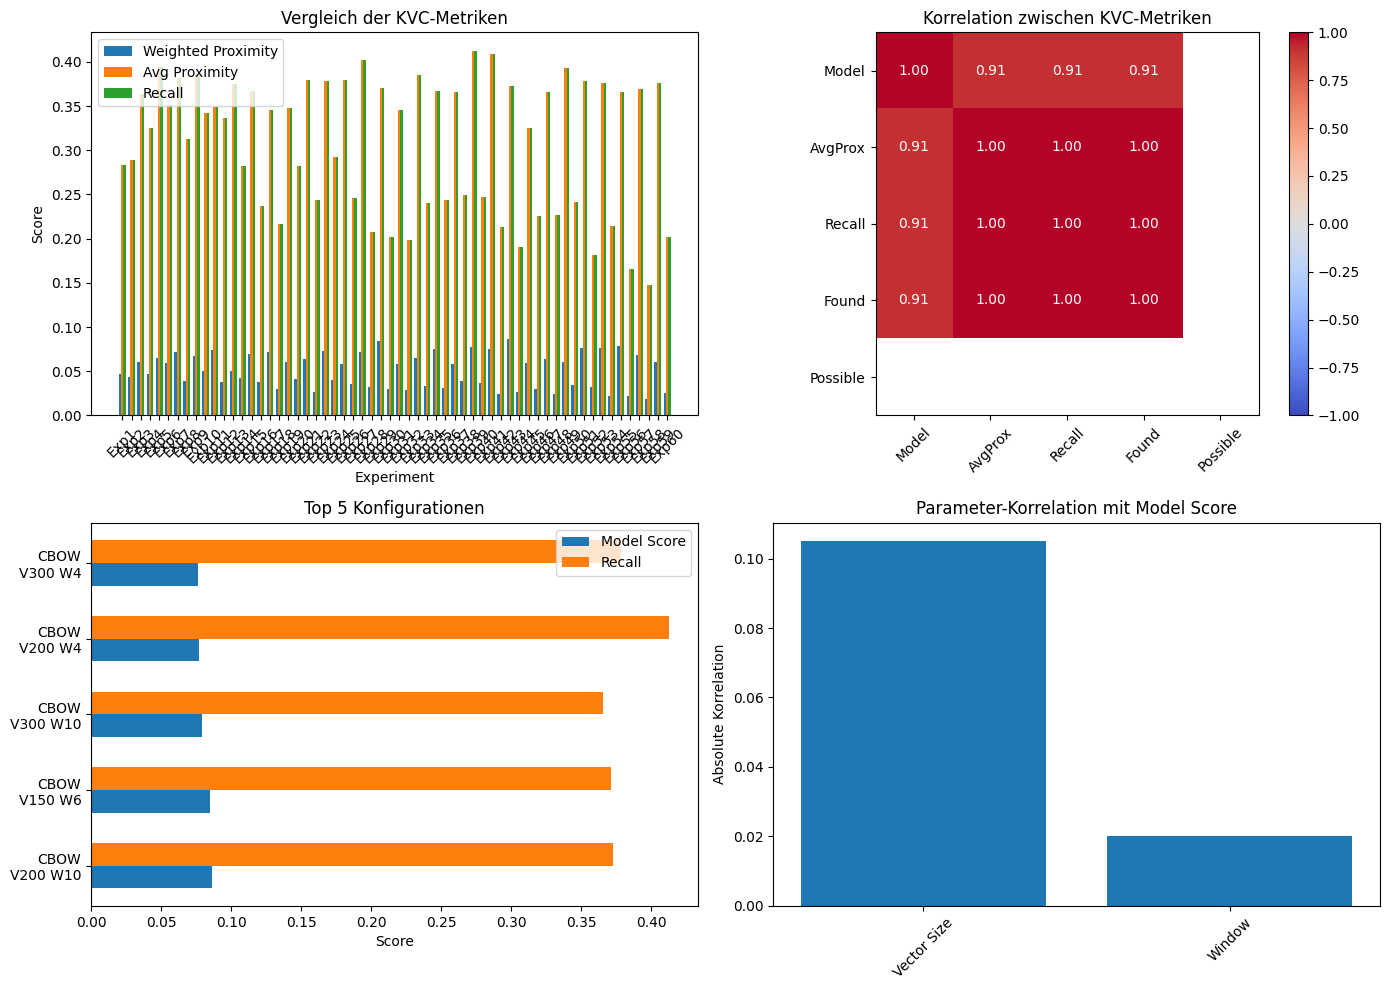

In [9]:
def plot_kvc_detailed_analysis(df):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # 1. Drei Hauptmetriken im Vergleich
    metrics = ['model_score', 'avg_proximity_score', 'overall_recall']
    metric_labels = ['Weighted Proximity', 'Avg Proximity', 'Recall']
    
    x = np.arange(len(df))
    width = 0.25
    
    for i, (metric, label) in enumerate(zip(metrics, metric_labels)):
        axes[0,0].bar(x + i*width, df[metric], width=width, label=label)
    
    axes[0,0].set_title('Vergleich der KVC-Metriken')
    axes[0,0].set_xlabel('Experiment')
    axes[0,0].set_ylabel('Score')
    axes[0,0].legend()
    axes[0,0].set_xticks(x + width)
    axes[0,0].set_xticklabels([f'Exp{i+1}' for i in range(len(df))], rotation=45)
    
    # 2. Korrelationsmatrix der Metriken
    kvc_metrics = ['model_score', 'avg_proximity_score', 'overall_recall',
                   'total_found_values', 'total_possible_values']
    corr_matrix = df[kvc_metrics].corr()
    
    im = axes[0,1].imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
    axes[0,1].set_title('Korrelation zwischen KVC-Metriken')
    axes[0,1].set_xticks(range(len(kvc_metrics)))
    axes[0,1].set_yticks(range(len(kvc_metrics)))
    axes[0,1].set_xticklabels(['Model', 'AvgProx', 'Recall', 'Found', 'Possible'], rotation=45)
    axes[0,1].set_yticklabels(['Model', 'AvgProx', 'Recall', 'Found', 'Possible'])
    
    for i in range(len(kvc_metrics)):
        for j in range(len(kvc_metrics)):
            text = axes[0,1].text(j, i, f'{corr_matrix.iloc[i, j]:.2f}',
                                ha="center", va="center", color="white")
    
    plt.colorbar(im, ax=axes[0,1])
    
    # 3. Top 5 Konfigurationen
    top5 = df.nlargest(5, 'model_score')[['Algorithmus', 'Vector Size', 'Window', 
                                         'model_score', 'overall_recall']]
    
    x_pos = np.arange(len(top5))
    axes[1,0].barh(x_pos - 0.15, top5['model_score'], height=0.3, label='Model Score')
    axes[1,0].barh(x_pos + 0.15, top5['overall_recall'], height=0.3, label='Recall')
    axes[1,0].set_yticks(x_pos)
    axes[1,0].set_yticklabels([f"{row['Algorithmus']}\nV{row['Vector Size']} W{row['Window']}" 
                              for _, row in top5.iterrows()])
    axes[1,0].set_xlabel('Score')
    axes[1,0].set_title('Top 5 Konfigurationen')
    axes[1,0].legend()
    
    # 4. Parameter Importance (vereinfacht)
    param_importance = {}
    for param in ['Vector Size', 'Window', 'Epochs', 'Negative Sampling']:
        if param in df.columns:
            correlation = df[param].corr(df['model_score'])
            param_importance[param] = abs(correlation)
    
    axes[1,1].bar(param_importance.keys(), param_importance.values())
    axes[1,1].set_title('Parameter-Korrelation mit Model Score')
    axes[1,1].set_ylabel('Absolute Korrelation')
    axes[1,1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()

plot_kvc_detailed_analysis(df)

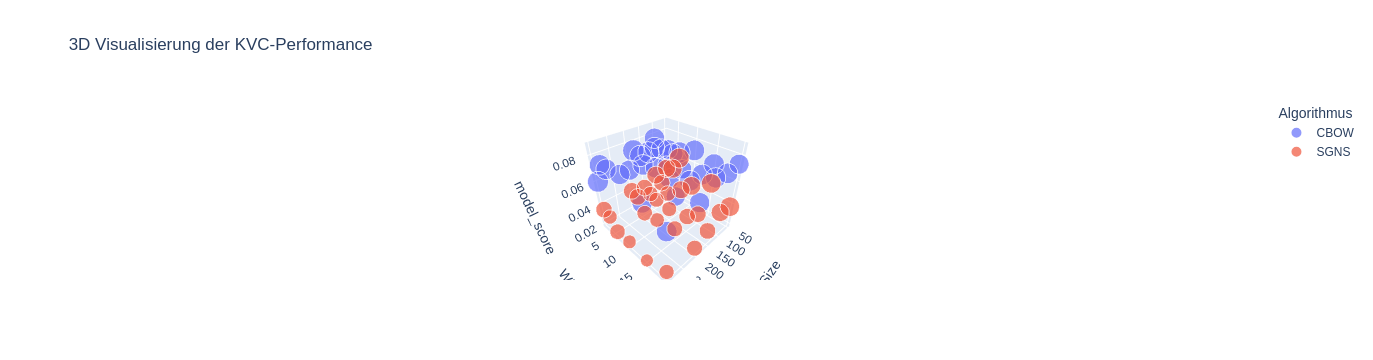

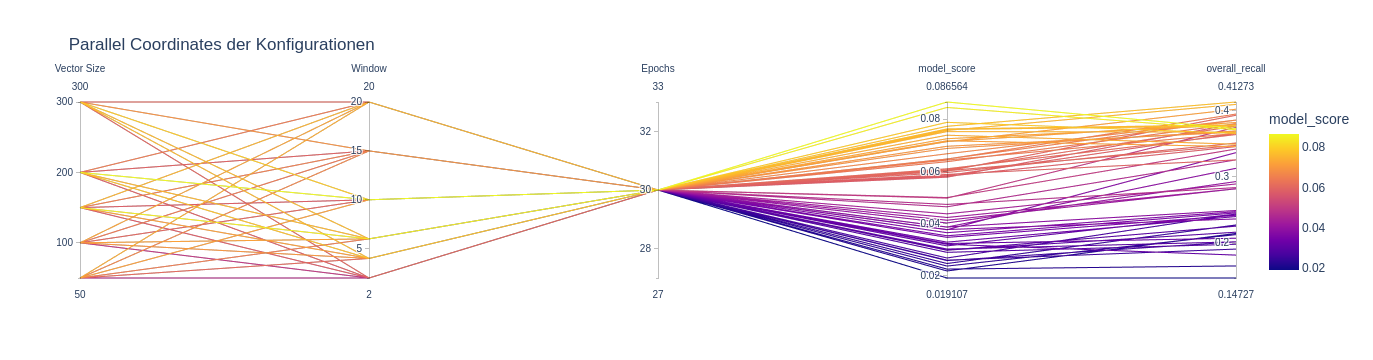

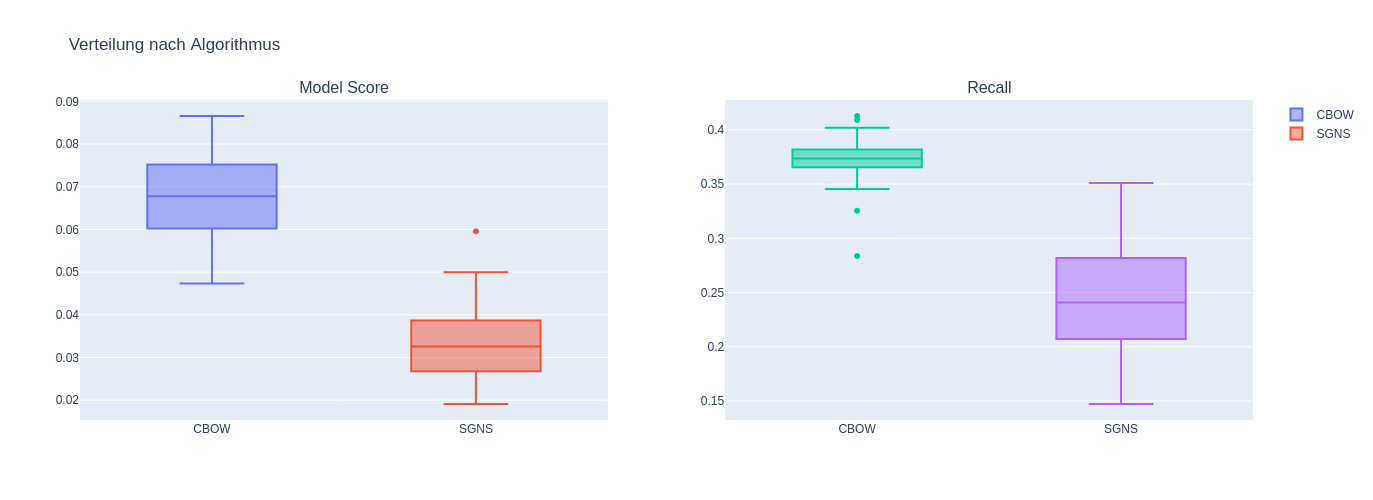

In [10]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

def create_interactive_dashboard(df):
    # 3D Scatter Plot
    fig = px.scatter_3d(df, x='Vector Size', y='Window', z='model_score',
                       color='Algorithmus', size='overall_recall',
                       hover_data=['Epochs', 'Negative Sampling', 'total_found_values'],
                       title='3D Visualisierung der KVC-Performance')
    fig.show()
    
    # Parallel Coordinates für Parameter
    fig = px.parallel_coordinates(df,
                                 dimensions=['Vector Size', 'Window', 'Epochs', 
                                           'model_score', 'overall_recall'],
                                 color='model_score',
                                 title='Parallel Coordinates der Konfigurationen')
    fig.show()
    
    # Boxplots nach Algorithmus
    fig = make_subplots(rows=1, cols=2, subplot_titles=('Model Score', 'Recall'))
    
    for i, metric in enumerate(['model_score', 'overall_recall']):
        for algo in df['Algorithmus'].unique():
            subset = df[df['Algorithmus'] == algo][metric]
            fig.add_trace(
                go.Box(y=subset, name=algo, showlegend=(i==0)),
                row=1, col=i+1
            )
    
    fig.update_layout(height=500, title_text="Verteilung nach Algorithmus")
    fig.show()

create_interactive_dashboard(df)

In [11]:
def generate_summary_report(df):
    print("="*60)
    print("KVC METRIKEN ZUSAMMENFASSUNG")
    print("="*60)
    
    # Beste Konfiguration
    best_idx = df['model_score'].idxmax()
    best = df.loc[best_idx]
    
    print(f"\n📊 BESTE KONFIGURATION:")
    print(f"   Algorithmus: {best['Algorithmus']}")
    print(f"   Vector Size: {best['Vector Size']}")
    print(f"   Window: {best['Window']}")
    print(f"   Model Score: {best['model_score']:.4f}")
    print(f"   Recall: {best['overall_recall']:.2%}")
    print(f"   Interpretation: {best['interpretation']}")
    
    # Statistiken
    print(f"\n📈 STATISTIKEN:")
    print(f"   Durchschnittlicher Model Score: {df['model_score'].mean():.4f}")
    print(f"   Range: [{df['model_score'].min():.4f}, {df['model_score'].max():.4f}]")
    print(f"   Std. Deviation: {df['model_score'].std():.4f}")
    
    # Erfolgsrate nach Interpretation
    print(f"\n🎯 ERFOLGSRATE:")
    for interpret in df['interpretation'].unique():
        count = len(df[df['interpretation'] == interpret])
        perc = count / len(df) * 100
        print(f"   {interpret}: {count} Experimente ({perc:.1f}%)")
    
    # Empfehlungen
    print(f"\n💡 EMPFEHLUNGEN:")
    
    # Check für CBOW vs Skip-Gram
    cbow_avg = df[df['Algorithmus'] == 'CBOW']['model_score'].mean()
    skipgram_avg = df[df['Algorithmus'] == 'Skip-Gram']['model_score'].mean() if 'Skip-Gram' in df['Algorithmus'].values else 0
    
    if cbow_avg > skipgram_avg:
        print(f"   • CBOW performt besser für KVC (Ø {cbow_avg:.4f})")
    else:
        print(f"   • Skip-Gram performt besser für KVC (Ø {skipgram_avg:.4f})")
    
    # Optimaler Vector Size Bereich
    best_vector_sizes = df.nlargest(3, 'model_score')['Vector Size'].unique()
    print(f"   • Optimale Vector Sizes: {', '.join(map(str, best_vector_sizes))}")

generate_summary_report(df)

KVC METRIKEN ZUSAMMENFASSUNG

📊 BESTE KONFIGURATION:
   Algorithmus: CBOW
   Vector Size: 200
   Window: 10
   Model Score: 0.0866
   Recall: 37.27%
   Interpretation: Ungenügend - Keys kodieren ihre Zeilenwerte kaum

📈 STATISTIKEN:
   Durchschnittlicher Model Score: 0.0508
   Range: [0.0191, 0.0866]
   Std. Deviation: 0.0192

🎯 ERFOLGSRATE:
   Ungenügend - Keys kodieren ihre Zeilenwerte kaum: 60 Experimente (100.0%)

💡 EMPFEHLUNGEN:
   • CBOW performt besser für KVC (Ø 0.0675)
   • Optimale Vector Sizes: 200, 150, 300
